In [1]:
# ============================================
# Notebook 2 - Investigation of the 
# efficiency dip at Lxy ~ 2.5-3.0 m
# ============================================
# This notebook tests several hypotheses 
# to explain the efficiency dip observed 
# at Lxy ~ 2.5-3.0 m in the barrel region.
#
# Common functions imported from notebook 1:
#   load_tree(), load_variables(), 
#   compute_DeltaR()
# ============================================


In [2]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
# Configuratioon of the ROOT file and binning for histograms and efficiency plots
Root_file = "\\Users\\ahlam\\Internship\\Fichier.root\\HSS\\outputFiles6.root"

pt_bins= np.linspace(0, 500, 26)
Lxy_bins = np.linspace(0, 5.0, 26)
Lz_bins = np.linspace(0, 7.0, 26)

ZONES = [(2.0, 2.3), (2.3, 2.5), (2.5, 2.7), (2.7, 3.0),(3.0, 3.5),(3.5, 4.0)]
ZONE_LABELS = ["2.0-2.3 m", "2.3-2.5 m", "2.5-2.7 m", "2.7-3.0 m", "3.0-3.5 m", "3.5-4.0 m"]
COLORS = ["green", "blue", "red", "orange","purple","brown"]

ATLAS_STYLE = {
    "font.family"          : "sans-serif",
    "font.size"            : 12,
    "axes.labelsize"       : 14,
    "axes.titlesize"       : 13,
    "axes.linewidth"       : 1.2,
    "axes.facecolor"       : "white",
    "xtick.labelsize"      : 12,
    "ytick.labelsize"      : 12,
    "xtick.direction"      : "in",
    "ytick.direction"      : "in",
    "xtick.top"            : True,
    "ytick.right"          : True,
    "xtick.minor.visible"  : True,
    "ytick.minor.visible"  : True,
    "xtick.major.size"     : 8,
    "xtick.minor.size"     : 4,
    "ytick.major.size"     : 8,
    "ytick.minor.size"     : 4,
    "figure.facecolor"     : "white",
    "legend.frameon"       : True,
    "legend.framealpha"    : 1.0,
    "legend.edgecolor"     : "black",
    "legend.fontsize"      : 10,
}
plt.rcParams.update(ATLAS_STYLE)

In [4]:
# Loading trigger
with uproot.open(Root_file) as f:
    triggers = [k for k in f["reco"].keys() if "CLEANllp" in k]

In [5]:
# Communs functions 
def load_tree(filepath):
    f = uproot.open(filepath)
    return f["particleLevel"], f["reco"]

def load_variables(tree_truth, tree_reco):
    evt_truth = ak.to_numpy(
        tree_truth["eventNumber"].array(library="ak"))
    evt_reco  = ak.to_numpy(
        tree_reco["eventNumber"].array(library="ak"))

    pt_raw = tree_truth["truth_alp_pt"].array(library="ak")
    eta_raw= tree_truth["truth_alp_eta"].array(library="ak")
    phi_raw= tree_truth["truth_alp_phi"].array(library="ak")
    Lx_raw = tree_truth["truth_alp_decayVtxX"].array(library="ak")
    Ly_raw = tree_truth["truth_alp_decayVtxY"].array(library="ak")
    Lz_raw = tree_truth["truth_alp_decayVtxZ"].array(library="ak")

    Lxy_all = np.sqrt(Lx_raw**2 + Ly_raw**2) / 1000.0
    Lz_all= np.abs(Lz_raw) / 1000.0
    eta_all = np.abs(eta_raw)
    in_barrel_all = (eta_all < 1.4) & (Lxy_all > 1.5) & (Lxy_all < 3.9)
    in_endcap_all = (eta_all > 1.4) & (Lz_all  > 3.5) & (Lz_all  < 6.0)
    in_calo_alp = in_barrel_all | in_endcap_all

    pt_mask = ak.where(in_calo_alp, pt_raw, 0.0)
    idx_max = ak.argmax(pt_mask, axis=1, keepdims=True)

    pt= ak.to_numpy(ak.fill_none(ak.max(pt_mask, axis=1), 0.0)) / 1000.0
    eta = ak.to_numpy(ak.fill_none(ak.firsts(eta_raw[idx_max], axis=1), 0.0))
    phi = ak.to_numpy(ak.fill_none(ak.firsts(phi_raw[idx_max], axis=1), 0.0))
    Lx = ak.to_numpy(ak.fill_none(ak.firsts(Lx_raw[idx_max],  axis=1), 0.0))
    Ly = ak.to_numpy(ak.fill_none(ak.firsts(Ly_raw[idx_max],  axis=1), 0.0))
    Lz = ak.to_numpy(ak.fill_none(ak.firsts(Lz_raw[idx_max],  axis=1), 0.0))

    Lxy = np.sqrt(Lx**2 + Ly**2) / 1000.0
    Lz = np.abs(Lz) / 1000.0

    df_truth = pd.DataFrame({
        "eventNumber" : evt_truth,
        "pt": pt, "eta" : eta, "phi" : phi,
        "Lxy" : Lxy, "Lz" : Lz
    })

    df_reco = pd.DataFrame({"eventNumber": evt_reco})
    for trig in triggers:
        df_reco[trig] = ak.to_numpy(
            tree_reco[trig].array(library="ak")).astype(bool)

    df = pd.merge(df_truth, df_reco, on="eventNumber", how="inner")

    trig_col = [c for c in df.columns if "CLEANllp" in c]
    df["pass_any_trig"] = df[trig_col].any(axis=1)
    df["in_barrel"] = (np.abs(df["eta"]) < 1.4) & \
                      (df["Lxy"] > 1.5) & (df["Lxy"] < 3.9)
    df["in_endcap"] = (np.abs(df["eta"]) > 1.4) & \
                      (df["Lz"]  > 3.5) & (df["Lz"]  < 6.0)
    df["in_calo"] = df["in_barrel"] | df["in_endcap"]
    return df


def compute_DeltaR(df, tree_reco, dR_cut=0.2):
    jet_eta  = tree_reco["EMTopoJet_eta"].array(library="ak")
    jet_phi  = tree_reco["EMTopoJet_phi"].array(library="ak")
    evt_reco = ak.to_numpy(
        tree_reco["eventNumber"].array(library="ak"))

    evt_to_idx = {evt: idx for idx, evt in enumerate(evt_reco)}
    llp_eta = df["eta"].to_numpy()
    llp_phi = df["phi"].to_numpy()

    matched = []
    for i in range(len(df)):
        evt = df["eventNumber"].iloc[i]
        reco_idx = evt_to_idx.get(evt, -1)
        if reco_idx == -1:
            matched.append(False)
            continue
        jets_eta_i = ak.to_numpy(jet_eta[reco_idx])
        jets_phi_i = ak.to_numpy(jet_phi[reco_idx])
        if len(jets_eta_i) == 0:
            matched.append(False)
            continue
        deta = jets_eta_i - llp_eta[i]
        dphi = (jets_phi_i - llp_phi[i] + np.pi) % (2*np.pi) - np.pi
        dR = np.sqrt(deta**2 + dphi**2)
        matched.append(bool(np.min(dR) < dR_cut))

    df = df.copy()
    df["matched_jet"] = matched
    return df

In [6]:
# Extraction of dataframes
def safe_float(arr_ak, reco_idx, jet_idx):
    try:
        val = ak.to_numpy(arr_ak[reco_idx])[jet_idx]
        if hasattr(val, '__len__'):
            return float(val[0]) if len(val) > 0 else np.nan
        return float(val)
    except Exception:
        return np.nan


In [7]:
# Loading varibles jet variables for the jet matching hypothesis. If a jet is found within the ΔR cut, the variables of the closest jet are loaded into the dataframe. Otherwise, NaN values are assigned.

def load_jet_variables(df, tree_reco, dR_cut=0.2):
    """
For each LLP, loads the reco jet variables from the closest 
reconstructed jet within a cone of size dR_cut (DeltaR < dR_cut).

Loaded variables:
-----------------
jet_EMFrac : Electromagnetic energy fraction (E_ECal / E_total)
jet_timing : Jet arrival time [ns]
jet_log_EMF : Logarithmic EM fraction, defined as log10(E_H / E_EM), used as the CalRatio discriminant
jet_NTrk : Number of tracks associated to the jet
jet_minDRTrk : Minimum distance between the jet axis and any track
jet_width : Jet width (second moment of the energy distribution)
min_dR : Minimum DeltaR between the LLP and all reconstructed jets in the event

If no jet is found within dR_cut, all variables are set to NaN 
for that event.
"""
    

    jet_eta = tree_reco["EMTopoJet_eta"].array(library="ak")
    jet_phi = tree_reco["EMTopoJet_phi"].array(library="ak")
    jet_emfrac = tree_reco["EMTopoJet_EMFrac_NOSYS"].array(library="ak")
    jet_timing = tree_reco["EMTopoJet_timing_NOSYS"].array(library="ak")
    jet_log_emf = tree_reco["EMTopoJet_log_EMF_NOSYS"].array(library="ak")
    jet_ntrk = tree_reco["EMTopoJet_NumTrkPt500_NOSYS"].array(library="ak")
    jet_mindr = tree_reco["EMTopoJet_minDRTrk_NOSYS"].array(library="ak")
    jet_width = tree_reco["EMTopoJet_width_NOSYS"].array(library="ak")
    jet_isclean = tree_reco["EMTopoJet_isClean_LooseBadLLP_NOSYS"].array(library="ak")
    evt_reco = ak.to_numpy(tree_reco["eventNumber"].array(library="ak"))

    evt_to_idx = {evt: idx for idx, evt in enumerate(evt_reco)}
    llp_eta= df["eta"].to_numpy()
    llp_phi= df["phi"].to_numpy()

    emfrac_list = []
    timing_list = []
    log_emf_list = []
    ntrk_list = []
    mindr_list = []
    width_list = []
    isclean_list = []
    min_dR_list= []

    for i in range(len(df)):
        evt = df["eventNumber"].iloc[i]
        reco_idx = evt_to_idx.get(evt, -1)

        if reco_idx == -1:
            emfrac_list.append(np.nan)
            timing_list.append(np.nan)
            log_emf_list.append(np.nan)
            ntrk_list.append(np.nan)
            mindr_list.append(np.nan)
            width_list.append(np.nan)
            isclean_list.append(np.nan)
            min_dR_list.append(np.nan)
            continue

        jets_eta_i = ak.to_numpy(jet_eta[reco_idx])
        jets_phi_i = ak.to_numpy(jet_phi[reco_idx])

        if len(jets_eta_i) == 0:
            emfrac_list.append(np.nan)
            timing_list.append(np.nan)
            log_emf_list.append(np.nan)
            ntrk_list.append(np.nan)
            mindr_list.append(np.nan)
            width_list.append(np.nan)
            isclean_list.append(np.nan)
            min_dR_list.append(np.nan)
            continue

        deta= jets_eta_i - llp_eta[i]
        dphi = (jets_phi_i - llp_phi[i] + np.pi) % (2*np.pi) - np.pi
        dR = np.sqrt(deta**2 + dphi**2)

        best_idx = int(np.argmin(dR))
        min_dR_list.append(float(dR[best_idx]))

        if dR[best_idx] < dR_cut:
            emfrac_list.append(safe_float(jet_emfrac,reco_idx, best_idx))
            timing_list.append(safe_float(jet_timing,reco_idx, best_idx))
            log_emf_list.append(safe_float(jet_log_emf, reco_idx, best_idx))
            ntrk_list.append(safe_float(jet_ntrk, reco_idx, best_idx))
            mindr_list.append(safe_float(jet_mindr, reco_idx, best_idx))
            width_list.append(safe_float(jet_width,reco_idx, best_idx))
            isclean_list.append(safe_float(jet_isclean, reco_idx, best_idx))
        else:
            emfrac_list.append(np.nan)
            timing_list.append(np.nan)
            log_emf_list.append(np.nan)
            ntrk_list.append(np.nan)
            mindr_list.append(np.nan)
            width_list.append(np.nan)
            isclean_list.append(np.nan)

    df = df.copy()
    df["jet_EMFrac"] = emfrac_list
    df["jet_timing"] = timing_list
    df["jet_log_EMF"]= log_emf_list
    df["jet_NTrk"] = ntrk_list
    df["jet_minDRTrk"]= mindr_list
    df["jet_width"] = width_list
    df["jet_isClean_LLP"] = isclean_list
    df["min_dR"] = min_dR_list
    return df


In [8]:
# filtering by zone. if the LLP is within the specified Lxy range, it is included in the returned DataFrame. Otherwise, it is excluded.
def get_zone(df, lmin, lmax):
    return df[(df["Lxy"] >= lmin) & (df["Lxy"] < lmax)]

In [9]:
# Hypothesis 1: Efficiency by zone.
# This function computes the efficiency of the trigger OR for each Lxy zone defined in ZONES, and plots the efficiency with error bars.
# The efficiency is calculated as the mean of the "pass_any_trig" column for each zone, and the error is computed using the binomial error formula. 
# The resulting efficiencies and errors are plotted as a bar chart with error bars, and the figure is saved to the specified output file.
# The idea is to see if the efficiency dip is observed in a specific Lxy zone, which could indicate that the trigger performance is affected by the LLP decay position.

def plot_efficiency_by_zone(df, output_file="dip_01_efficiency.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    effs, errs = [], []
    for lmin, lmax in ZONES:
        zone = get_zone(df, lmin, lmax)
        eff = zone["pass_any_trig"].mean()
        err= np.sqrt(eff * (1 - eff) / len(zone))
        effs.append(eff)
        errs.append(err)

    bars = ax.bar(ZONE_LABELS, effs,
                  color=COLORS, edgecolor="black", alpha=0.8)
    ax.errorbar(ZONE_LABELS, effs, yerr=errs,
                fmt="none", color="black", capsize=5)
    #ax.axhline(0.5, color="black", linestyle="--", alpha=0.4, label="55% reference")
    ax.set_ylabel("Trigger OR efficiency", fontsize=12)
    ax.set_title("Hypothesis 1-Efficiency by Lxy zone\n"
                 "(pass_any_trig)", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, effs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.02, f"{val:.3f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved : {output_file}")

In [10]:
# Hypothesis 2: EMFrac by Lxy zone.
# This function computes the mean EMFrac of the closest jet for each Lxy zone defined in ZONES, and plots the mean EMFrac as a bar chart.
# The mean EMFrac is calculated as the mean of the "jet_EMFrac" column for each zone. The resulting mean EMFrac values are plotted as a bar chart, and the figure is saved to the specified output file.
# The idea is to see if the EMFrac of the closest jet is lower in the Lxy zone where the efficiency dip is observed, which could indicate that the jets are more hadronic and less likely to pass the trigger.

def plot_emfrac_by_zone(df, output_file="dip_02_emfrac.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    emfs = [get_zone(df, a, b)["jet_EMFrac"].mean() for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, emfs,
                  color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Mean EMFrac", fontsize=12)
    ax.set_title("Hypothesis 2- EMFrac by Lxy zone", fontsize=12)
    for bar, val in zip(bars, emfs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.001, f"{val:.3f}",
                ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")


In [11]:
# Hypothesis 3: Timing by Lxy zone 
# This function computes the mean jet timing of the closest jet for each Lxy zone defined in ZONES, and plots the mean jet timing as a bar chart.
# The mean jet timing is calculated as the mean of the "jet_timing" column for each zone. The resulting mean jet timing values are plotted as a bar chart,
# and the figure is saved to the specified output file.
# The idea is to see if the jet timing of the closest jet is delayed in the Lxy zone where the efficiency dip is observed, 
# which could indicate that the jets are arriving later and may not be reconstructed in time for the trigger.
def plot_timing_by_zone(df, output_file="dip_03_timing.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    timings = [get_zone(df, a, b)["jet_timing"].mean() for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, timings,
                  color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Mean jet timing [ns]", fontsize=12)
    ax.set_title("Hypothesis 3- Jet timing by Lxy zone", fontsize=12)
    for bar, val in zip(bars, timings):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.05, f"{val:.2f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")

In [12]:
#Hypothesis 4: PT moyen
# This function computes the mean pT of the closest jet for each Lxy zone defined in ZONES, and plots the mean pT as a bar chart.
# The mean pT is calculated as the mean of the "pt" column for each zone. The resulting mean pT values are plotted as a bar chart,
#  and the figure is saved to the specified output file.
# The idea is to see if the pT of the closest jet is lower in the Lxy zone where the efficiency dip is observed, which could indicate 
# that the jets are softer and less likely to pass the trigger.
def plot_pt_by_zone(df, output_file="dip_04_pt.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    pts = [get_zone(df, a, b)["pt"].mean() for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, pts,color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Mean LLP pT [GeV]", fontsize=12)
    ax.set_title("Hypothesis 4- Mean pT by Lxy zone", fontsize=12)
    for bar, val in zip(bars, pts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 1, f"{val:.1f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")


In [13]:
# Hypothesis 5: |η| moyen
# This function computes the mean |η| of the closest jet for each Lxy zone defined in ZONES, and plots the mean |η| as a bar chart.
# The mean |η| is calculated as the mean of the "eta" column for each zone. The resulting mean |η| values are plotted as a bar chart,
#  and the figure is saved to the specified output file.
# The idea is to see if the |η| of the closest jet is lower in the Lxy zone where the efficiency dip is observed, which could indicate 
# that the jets are more central and less likely to pass the trigger.
def plot_eta_by_zone(df, output_file="dip_05_eta.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    etas = [np.abs(get_zone(df, a, b)["eta"]).mean() for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, etas, color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Mean |η|", fontsize=12)
    ax.set_title("Hypothesis 5- Mean |η| by Lxy zone", fontsize=12)
    for bar, val in zip(bars, etas): ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.005, f"{val:.3f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")

In [14]:
# Hypotheis 6: isClean_LooseBadLLP 
# This function computes the fraction of jets that are classified as "isClean_LooseBadLLP" for each Lxy zone defined in ZONES, and plots the fraction as a bar chart.
# The fraction is calculated as the mean of the "jet_isClean_LLP" column for each zone. The resulting fraction values are plotted as a bar chart, 
# and the figure is saved to the specified output file.
# The idea is to see if the fraction of jets that are classified as "isClean_LooseBadLLP" is lower in the Lxy zone where the efficiency dip is observed, which 
# could indicate that the jets are more likely to be classified as "bad"
def plot_isClean_by_zone(df, output_file="dip_06_isClean.png"):
    """
    Variable : jet_isClean_LLP = isClean_LooseBadLLP (officiel ATLAS)
    Hypothèse : fraction de jets propres plus basse dans le creux ?
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    fracs = [get_zone(df, a, b)["jet_isClean_LLP"].mean()
             for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, fracs,
                  color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Fraction jets isClean_LooseBadLLP", fontsize=12)
    ax.set_title("Hypothesis 6- Fraction jets by Lxy zone", fontsize=12)
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, fracs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.01, f"{val:.3f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")


In [15]:
# Hypothesis 7 : Quality of the jet matching 
# This function computes the fraction of jets that are matched to the LLP within a ΔR < 0.2 for each Lxy zone defined in ZONES, and plots the fraction as a bar chart.
# The fraction is calculated as the mean of the "min_dR" column for each zone, where the condition is that "min_dR" < 0.2. The resulting fraction values are plotted as
#  a bar chart, and the figure is saved to the specified output file.
# The idea is to see if the fraction of jets that are matched to the LLP within a ΔR < 0.2 is lower in the Lxy zone where the efficiency dip is observed, which could
#  indicate that the jets are not well matched to the LLP and may not be reconstructed properly.

def plot_deltaR_by_zone(df, output_file="dip_07_deltaR.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    fracs = [(get_zone(df, a, b)["min_dR"] < 0.2).mean()
             for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, fracs,color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Fraction ΔR < 0.2", fontsize=12)
    ax.set_title("Hypothesis 7- Matching quality ΔR by Lxy zone",fontsize=12)
    ax.set_ylim(0, 1.1)
    for bar, val in zip(bars, fracs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.01, f"{val:.3f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")

In [16]:
# Hypothesis 8: Number of jets matched (ΔR < 0.2)
# This function computes the mean number of tracks associated to the closest jet for each Lxy zone defined in ZONES, and plots the mean number of tracks as a bar chart.
# The mean number of tracks is calculated as the mean of the "jet_NTrk" column for each zone. The resulting mean number of tracks values are plotted as a bar chart, and 
# the figure is saved to the specified output file.
# The idea is to see if the mean number of tracks associated to the closest jet is lower in the Lxy zone where the efficiency dip is observed, which could indicate that 
# the jets are less likely to be reconstructed with enough tracks to pass the trigger
def plot_ntrk_by_zone(df, output_file="dip_08_ntrk.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    ntrks = [get_zone(df, a, b)["jet_NTrk"].mean() for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, ntrks,
                  color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Mean NTrk (number of associated tracks)", fontsize=12)
    ax.set_title("Hypothesis 8- NTrk by Lxy zone\n"
                 "(track isolation criterion)", fontsize=12)
    for bar, val in zip(bars, ntrks):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.01, f"{val:.2f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")


In [17]:
# Hypothesis 9: Largeur du jet (width)
# This function computes the mean jet width of the closest jet for each Lxy zone defined in ZONES, and plots the mean jet width as a bar chart.
# The mean jet width is calculated as the mean of the "jet_width" column for each zone. The resulting mean jet width values are plotted as a bar chart,
#  and the figure is saved to the specified output file.
# The idea is to see if the mean jet width of the closest jet is larger in the Lxy zone where the efficiency dip is observed, which could indicate that
#  the jets are more diffuse and less likely to pass the trigger

def plot_width_by_zone(df, output_file="dip_09_width.png"):
    fig, ax = plt.subplots(figsize=(8, 6))
    widths = [get_zone(df, a, b)["jet_width"].mean() for a, b in ZONES]
    bars = ax.bar(ZONE_LABELS, widths,
                  color=COLORS, edgecolor="black", alpha=0.8)
    ax.set_ylabel("Mean jet width", fontsize=12)
    ax.set_title("Hypothesis 9- Jet width by Lxy zone", fontsize=12)
    for bar, val in zip(bars, widths):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + 0.001, f"{val:.3f}",
                ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()
    print(f"Figure saved: {output_file}")


In [18]:
# Statistics 
# this function performs a statistical test to compare the trigger efficiency between two Lxy zones: the peak zone (2.3-2.5 m) and the dip zone (2.6-2.8 m).
# The function calculates the efficiency and its uncertainty for each zone, and then computes the z-score to quantify the significance of the difference in 
# efficiency between the two zones. 
# The z-score is calculated as the difference in efficiency divided by the combined uncertainty. If the z-score is greater than 3, it indicates that the 
# difference in efficiency is statistically significant and not likely due to random fluctuations
def statistical_test(df):
    zone_peak = get_zone(df, 2.3, 2.5)
    zone_dip = get_zone(df, 2.6, 2.8)

    eff_peak = zone_peak["pass_any_trig"].mean()
    eff_dip = zone_dip["pass_any_trig"].mean()
    sig_peak = np.sqrt(eff_peak * (1 - eff_peak) / len(zone_peak))
    sig_dip = np.sqrt(eff_dip  * (1 - eff_dip)  / len(zone_dip))
    denom= np.sqrt(sig_peak**2 + sig_dip**2)
    z_score= (eff_peak - eff_dip) / denom if denom > 0 else np.nan

    print("\n===== STATISTICAL TEST =====")
    print(f"N peak zone: {len(zone_peak)}")
    print(f"N dip  zone: {len(zone_dip)}")
    print(f"Efficiency peak  : {eff_peak:.4f}")
    print(f"Efficiency dip: {eff_dip:.4f}")
    print(f"Z-score: {z_score:.2f}")
    if z_score > 3:
        print("The dip is NOT a statistical fluctuation !")
    else:
        print("The dip may be a statistical fluctuation.")
    return z_score

N total          : 100000
N in calo        : 40129
N matched        : 33220

N barrel matched : 21995
=== Investigation du creux à Lxy ~ 2.5-3.0 m ===

N events : 21995

Hypothèse 1 — Efficacité par zone


C:\Users\ahlam\AppData\Local\Temp\ipykernel_29972\2970381726.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


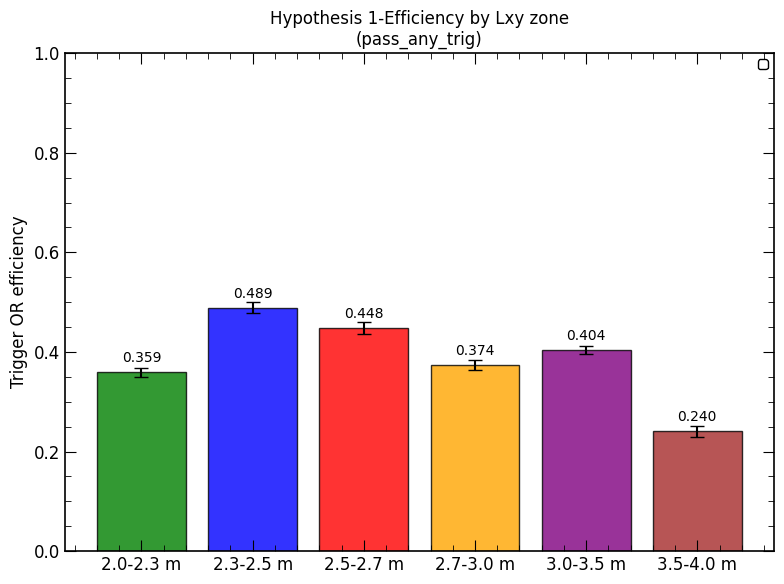

Figure saved : dip_01_efficiency.png

Hypothèse 2 — EMFrac


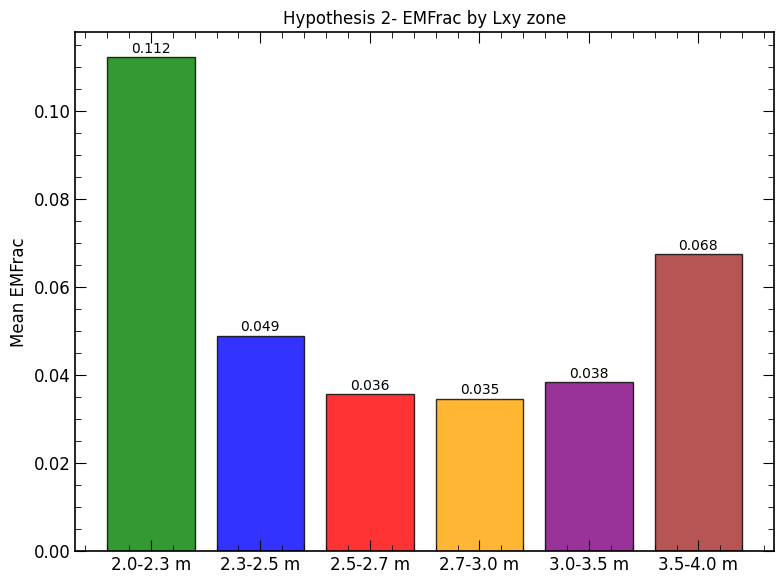

Figure saved: dip_02_emfrac.png

Hypothèse 3 — Timing


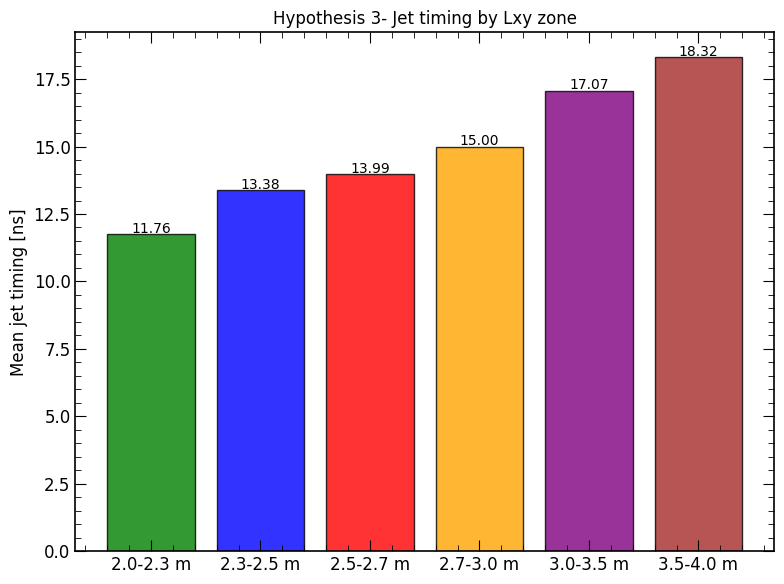

Figure saved: dip_03_timing.png

Hypothèse 4 — pT moyen


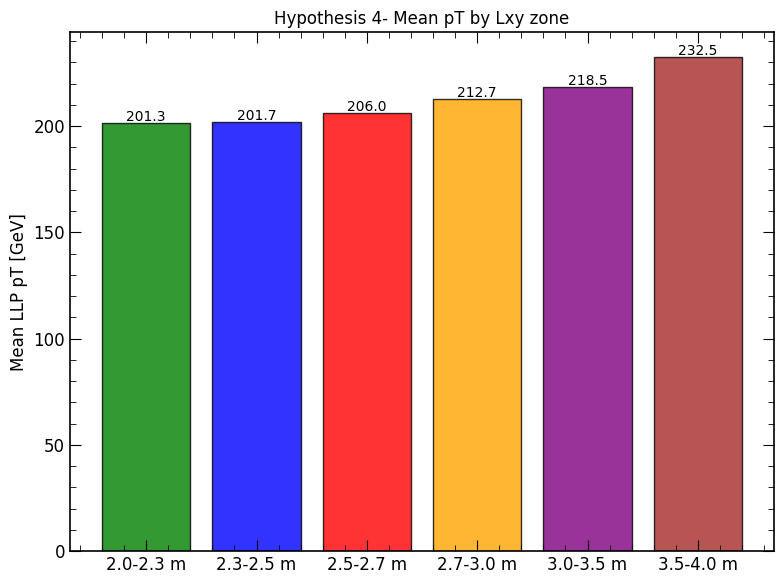

Figure saved: dip_04_pt.png

Hypothèse 5 — |η| moyen


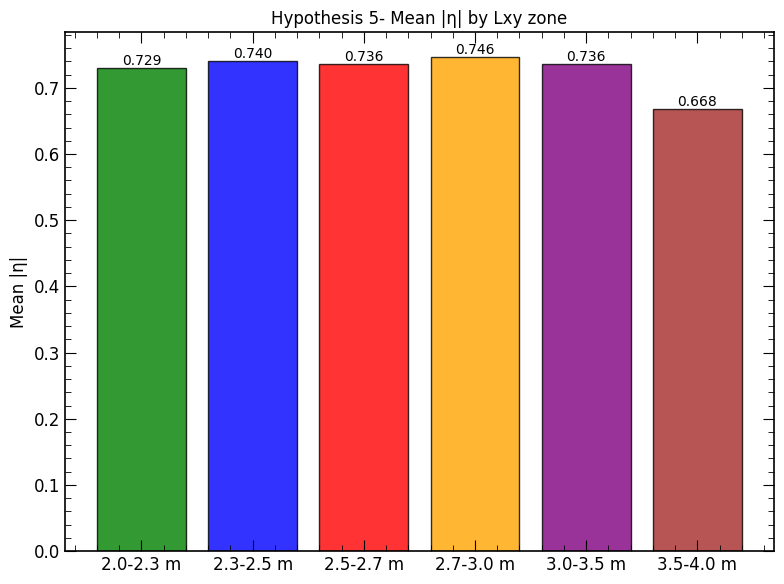

Figure saved: dip_05_eta.png

Hypothèse 6 — isClean_LooseBadLLP (officiel ATLAS)


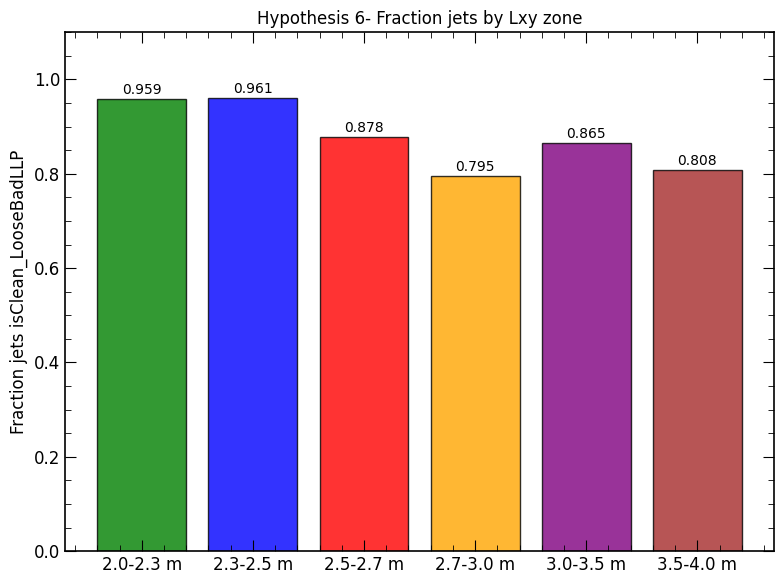

Figure saved: dip_06_isClean.png

Hypothèse 7 — Qualité matching ΔR


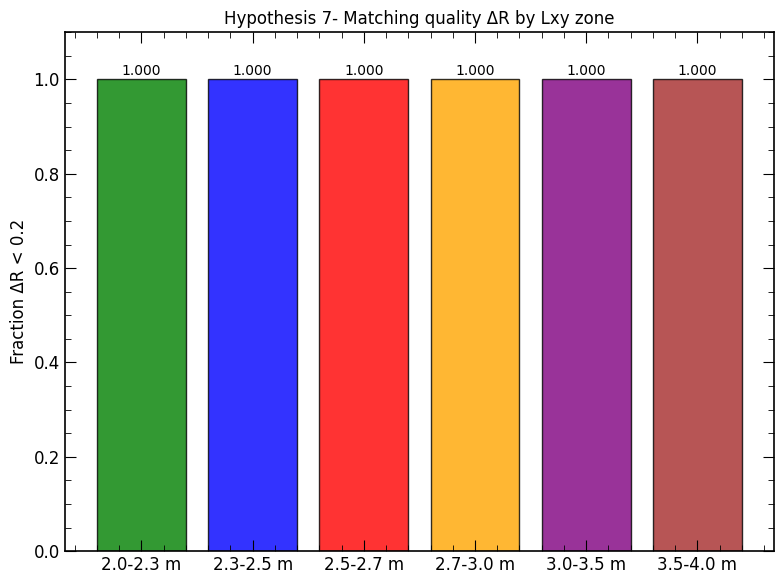

Figure saved: dip_07_deltaR.png

Hypothèse 8 — NTrk


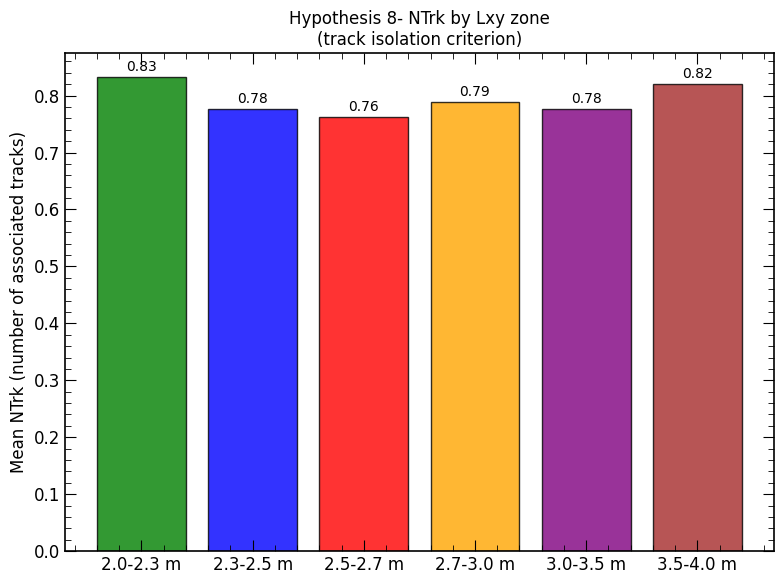

Figure saved: dip_08_ntrk.png

Hypothèse 9 — Jet width


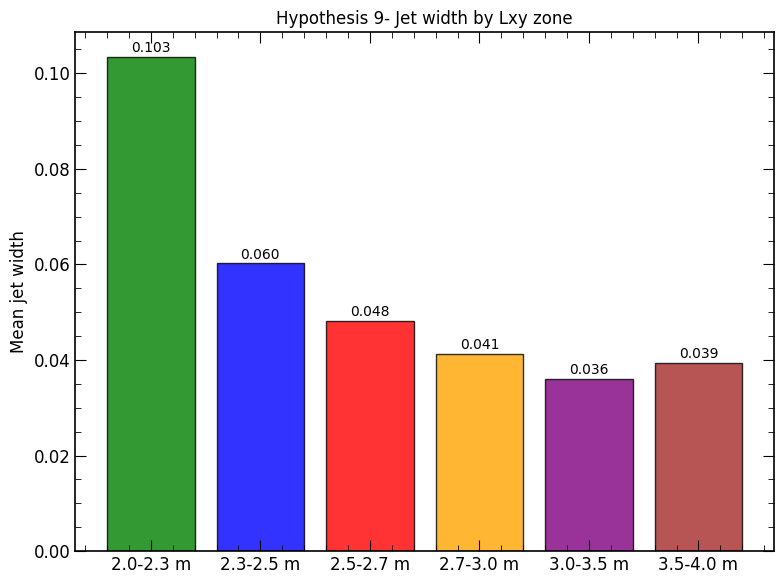

Figure saved: dip_09_width.png

Test statistique

===== STATISTICAL TEST =====
N peak zone: 2096
N dip  zone: 1780
Efficiency peak  : 0.4885
Efficiency dip: 0.3742
Z-score: 7.22
The dip is NOT a statistical fluctuation !

=== Investigation complete ! ===


In [ ]:

# Main investigation


def main_investigation(df):
    print("=== Investigation du creux à Lxy ~ 2.5-3.0 m ===\n")
    print(f"N events : {len(df)}")

    print("\nHypothèse 1 — Efficacité par zone")
    plot_efficiency_by_zone(df)

    print("\nHypothèse 2 — EMFrac")
    plot_emfrac_by_zone(df)

    print("\nHypothèse 3 — Timing")
    plot_timing_by_zone(df)

    print("\nHypothèse 4 — pT moyen")
    plot_pt_by_zone(df)

    print("\nHypothèse 5 — |η| moyen")
    plot_eta_by_zone(df)

    print("\nHypothèse 6 — isClean_LooseBadLLP (officiel ATLAS)")
    plot_isClean_by_zone(df)

    print("\nHypothèse 7 — Qualité matching ΔR")
    plot_deltaR_by_zone(df)

    print("\nHypothèse 8 — NTrk")
    plot_ntrk_by_zone(df)

    print("\nHypothèse 9 — Jet width")
    plot_width_by_zone(df)

    print("\nTest statistique")
    statistical_test(df)

    print("\n=== Investigation complete ! ===")


# Exécution

tree_truth, tree_reco = load_tree(Root_file)
df = load_variables(tree_truth, tree_reco)
df = compute_DeltaR(df, tree_reco, dR_cut=0.2)

print(f"N total  : {len(df)}")
print(f"N in calo : {df['in_calo'].sum()}")
print(f"N matched  : {(df['in_calo'] & df['matched_jet']).sum()}")


df = load_jet_variables(df, tree_reco)

# 3. Nettoyer les sentinelles -99
sentinel_cols = ["jet_timing", "jet_log_EMF", "jet_minDRTrk", "jet_width"]
for col in sentinel_cols:
    df[col] = df[col].replace(-99.0, np.nan)


df_bm = df[
    df["in_calo"] &
    df["in_barrel"] &
    df["matched_jet"]
].copy()

print(f"\nN barrel matched : {len(df_bm)}")






main_investigation(df_bm)